In [1]:
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
install("torch-geometric")
#install("torch-scatter")
#install("torch-sparse")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.7 MB/s eta 0:00:00


In [2]:
import os
print(os.listdir("/kaggle/input/datasets/senbati/verified-goad"))

['zoom.csv', 'goad_forest.json', 'heterodata.pt', 'training_examples.json']


In [3]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import GCNConv
 
# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
 
# Kaggle input paths
HETERODATA_PATH  = Path("/kaggle/input/datasets/senbati/verified-goad/heterodata.pt")
EXAMPLES_PATH    = Path("/kaggle/input/datasets/senbati/verified-goad/training_examples.json")
CHECKPOINT_PATH  = Path("/kaggle/working/best_model.pt")

Device: cuda


In [4]:
# load graph
import torch

data = torch.load(HETERODATA_PATH, map_location=DEVICE, weights_only=False)
print("HeteroData loaded:")
print(f"  Nodes      : {data['node'].num_nodes}")
print(f"  Feature dim: {data['node'].x.shape[1]}")
print(f"  Edge types : {len(data.edge_types)}")
for et in data.edge_types:
    print(f"    {et[1]:<35}: {data[et].edge_index.shape[1]} edges")
 
# load training examples
with open(EXAMPLES_PATH) as f:
    all_examples = json.load(f)
 
# split constrained / unconstrained
constrained   = [e for e in all_examples if e["mode"] == "constrained"]
unconstrained = [e for e in all_examples if e["mode"] == "unconstrained"]
 
print(f"\nTraining examples:")
print(f"  Constrained   : {len(constrained)}")
print(f"  Unconstrained : {len(unconstrained)}")
print(f"  Total         : {len(all_examples)}")
 
# flatten all edge indices into a single homogeneous edge_index
# GCN treats all edge types equally — we merge them
# collect all edges on CPU
all_edges = []
for et in data.edge_types:
    all_edges.append(data[et].edge_index.cpu())

# process on CPU
edge_index_full = torch.cat(all_edges, dim=1)
edge_index_full = torch.unique(edge_index_full, dim=1)

# move everything to device at once
edge_index_full = edge_index_full.to(DEVICE)
X = data["node"].x.to(DEVICE)
N = X.shape[0]

print(f"Homogeneous edge_index: {edge_index_full.shape[1]} edges (merged + deduped)")
print(f"Node feature matrix: {X.shape}")
 

HeteroData loaded:
  Nodes      : 352
  Feature dim: 14
  Edge types : 22
    owns                               : 278 edges
    genericwrite                       : 357 edges
    writeowner                         : 541 edges
    allextendedrights                  : 83 edges
    writedacl                          : 542 edges
    readgmsapassword                   : 2 edges
    genericall                         : 627 edges
    addkeycredentiallink               : 66 edges
    forcechangepassword                : 1 edges
    readlapspassword                   : 2 edges
    memberof                           : 135 edges
    addmember                          : 1 edges
    addself                            : 1 edges
    getchanges                         : 8 edges
    getchangesall                      : 6 edges
    getchangesinfilteredset            : 5 edges
    contains                           : 150 edges
    crossforesttrust                   : 4 edges
    sameforesttrust         

In [5]:
HIDDEN_DIM = 64   # GCN hidden dimension = embedding size
POLICY_DIM = 32   # policy head hidden layer
 
class GCNEncoder(nn.Module):
    """
    Two-layer GCN that produces a 64D embedding per node.
    Each node aggregates features from its 1-hop and 2-hop neighbors.
    After 2 layers a node 'knows about' everything within 2 hops.
    """
    def __init__(self, in_channels: int, hidden_dim: int):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim,  hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
 
    def forward(self, x: torch.Tensor,
                edge_index: torch.Tensor) -> torch.Tensor:
        # layer 1: aggregate 1-hop neighborhood
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
 
        # layer 2: aggregate 2-hop neighborhood
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
 
        return x   # [N, hidden_dim]
 
 
class PolicyHead(nn.Module):
    """
    Scores candidate neighbors given the current node embedding.
    Input  : current node embedding [64D]
    Output : scalar score per neighbor
    
    For each candidate neighbor:
        score = MLP( embed(current) * embed(neighbor) )
    Element-wise product captures compatibility between current
    position and candidate next hop.
    """
    def __init__(self, hidden_dim: int, policy_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, policy_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(policy_dim, 1),
        )
 
    def forward(self, current_emb: torch.Tensor,
                neighbor_embs: torch.Tensor) -> torch.Tensor:
        """
        current_emb   : [64D]
        neighbor_embs : [K x 64D]  where K = number of candidates
        returns       : [K] scores
        """
        # broadcast current embedding across all neighbors
        current_expanded = current_emb.unsqueeze(0).expand_as(neighbor_embs)
 
        # element-wise product: captures structural compatibility
        interaction = current_expanded * neighbor_embs   # [K, 64]
 
        scores = self.mlp(interaction).squeeze(-1)       # [K]
        return scores
 
 
class GNNNavigator(nn.Module):
    """
    Full model: GCNEncoder + PolicyHead.
    
    Usage:
        node_embeddings = model.encode(x, edge_index)
        scores = model.score(node_embeddings, current_idx, neighbor_idxs)
    """
    def __init__(self, in_channels: int,
                 hidden_dim: int, policy_dim: int):
        super().__init__()
        self.encoder     = GCNEncoder(in_channels, hidden_dim)
        self.policy_head = PolicyHead(hidden_dim, policy_dim)
 
    def encode(self, x: torch.Tensor,
               edge_index: torch.Tensor) -> torch.Tensor:
        return self.encoder(x, edge_index)
 
    def score(self, embeddings: torch.Tensor,
              current_idx: int,
              neighbor_idxs: list) -> torch.Tensor:
        """
        Score candidate neighbors for a given current node.
        Returns raw logits — softmax applied in loss / inference.
        """
        current_emb   = embeddings[current_idx]               # [64]
        neighbor_embs = embeddings[torch.tensor(neighbor_idxs,
                                   device=embeddings.device)] # [K, 64]
        return self.policy_head(current_emb, neighbor_embs)   # [K]
 
 
# instantiate
model = GNNNavigator(
    in_channels = X.shape[1],
    hidden_dim  = HIDDEN_DIM,
    policy_dim  = POLICY_DIM,
).to(DEVICE)
 
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 7,489
GNNNavigator(
  (encoder): GCNEncoder(
    (conv1): GCNConv(14, 64)
    (conv2): GCNConv(64, 64)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (policy_head): PolicyHead(
    (mlp): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


In [6]:
def get_neighbors(edge_index: torch.Tensor, node_idx: int,
                  n_nodes: int) -> list:
    """
    Return all neighbor indices of node_idx in the graph.
    Looks at both directions (src→dst and dst→src) since
    AD relationships are often bidirectionally meaningful.
    """
    src, dst = edge_index
    # outgoing edges from node_idx
    mask_out = (src == node_idx)
    # incoming edges to node_idx (reverse direction)
    mask_in  = (dst == node_idx)
 
    neighbors = torch.cat([
        dst[mask_out],
        src[mask_in],
    ]).unique().tolist()
 
    # remove self-loops
    neighbors = [n for n in neighbors if n != node_idx]
    return neighbors
 
 
def compute_loss(model: GNNNavigator,
                 embeddings: torch.Tensor,
                 edge_index: torch.Tensor,
                 example: dict) -> torch.Tensor | None:
    """
    Compute weighted cross-entropy loss for one training example.
 
    The model scores all neighbors of current_node.
    Loss = cross_entropy(scores, position_of_correct_next_hop)
         * effective_weight
 
    Returns None if current node has no neighbors (dead end in graph).
    """
    current_idx  = example["current_idx"]
    next_hop_idx = example["next_hop_idx"]
    eff_weight   = example.get("eff_weight", 1.0)
 
    neighbors = get_neighbors(edge_index, current_idx, embeddings.shape[0])
 
    if len(neighbors) == 0:
        return None   # isolated node — skip
 
    # check correct next hop is reachable
    if next_hop_idx not in neighbors:
        # next hop not a direct neighbor in graph
        # add it as a candidate anyway so model can learn the transition
        neighbors.append(next_hop_idx)
 
    # position of correct next hop in the neighbor list
    label_pos = neighbors.index(next_hop_idx)
    label     = torch.tensor([label_pos], dtype=torch.long,
                              device=embeddings.device)
 
    # score all candidate neighbors
    scores = model.score(embeddings, current_idx, neighbors)  # [K]
    scores = scores.unsqueeze(0)                               # [1, K]
 
    loss = F.cross_entropy(scores, label)
    return loss * eff_weight
 
 
def train_epoch(model: GNNNavigator,
                x: torch.Tensor,
                edge_index: torch.Tensor,
                examples: list,
                optimizer: torch.optim.Optimizer) -> float:
    """
    One full training epoch over all examples.
    Embeddings are recomputed once per epoch (full-batch).
    """
    model.train()
    optimizer.zero_grad()
 
    # encode full graph once — efficient for small graphs
    embeddings = model.encode(x, edge_index)  # [N, 64]
 
    total_loss  = torch.tensor(0.0, device=x.device, requires_grad=True)
    valid_count = 0
 
    shuffled = examples.copy()
    random.shuffle(shuffled)
 
    for example in shuffled:
        loss = compute_loss(model, embeddings, edge_index, example)
        if loss is None:
            continue
        total_loss  = total_loss + loss
        valid_count += 1
 
    if valid_count == 0:
        return 0.0
 
    mean_loss = total_loss / valid_count
    mean_loss.backward()
 
    # gradient clipping — prevents exploding gradients on small datasets
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
 
    optimizer.step()
    return mean_loss.item()

Starting training...
  Examples per epoch : 66
  Epochs             : 500
  Learning rate      : 0.005
----------------------------------------
Epoch    1  loss: 1.3270  best: 1.3270  lr: 0.00500
Epoch   50  loss: 0.5554  best: 0.3691  lr: 0.00500
Epoch  100  loss: 0.3307  best: 0.1524  lr: 0.00500
Epoch  150  loss: 0.1512  best: 0.1256  lr: 0.00250
Epoch  200  loss: 0.2490  best: 0.0845  lr: 0.00250
Epoch  250  loss: 0.1450  best: 0.0731  lr: 0.00250
Epoch  300  loss: 0.2054  best: 0.0731  lr: 0.00125
Epoch  350  loss: 0.0899  best: 0.0731  lr: 0.00125
Epoch  400  loss: 0.1321  best: 0.0731  lr: 0.00125
Epoch  450  loss: 0.1296  best: 0.0702  lr: 0.00063
Epoch  500  loss: 0.0953  best: 0.0654  lr: 0.00063

Training complete. Best loss: 0.0654
Checkpoint saved → /kaggle/working/best_model.pt


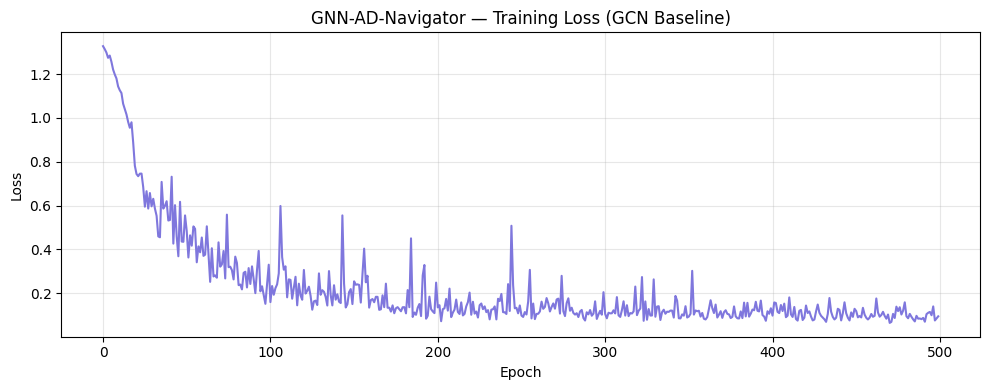

Loss curve saved.


In [7]:
DEVICE = torch.device("cpu")
# force everything back to CPU
model = model.cpu()
X = X.cpu()
edge_index_full = edge_index_full.cpu()


EPOCHS    = 500
LR        = 0.005
LOG_EVERY = 50

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=150, gamma=0.5
)
 
best_loss   = float("inf")
loss_history = []
 
print("Starting training...")
print(f"  Examples per epoch : {len(all_examples)}")
print(f"  Epochs             : {EPOCHS}")
print(f"  Learning rate      : {LR}")
print("-" * 40)
 
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, X, edge_index_full,
                       all_examples, optimizer)
    scheduler.step()
    loss_history.append(loss)
 
    if loss < best_loss:
        best_loss = loss
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "loss":        loss,
        }, CHECKPOINT_PATH)
 
    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(f"Epoch {epoch:>4}  loss: {loss:.4f}  "
              f"best: {best_loss:.4f}  lr: {scheduler.get_last_lr()[0]:.5f}")
 
print(f"\nTraining complete. Best loss: {best_loss:.4f}")
print(f"Checkpoint saved → {CHECKPOINT_PATH}")
 
# loss curve
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5, color="#7F77DD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN-AD-Navigator — Training Loss (GCN Baseline)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved.")
 

In [8]:
def evaluate(model: GNNNavigator,
             x: torch.Tensor,
             edge_index: torch.Tensor,
             examples: list,
             k: int = 3) -> dict:
    """
    Metrics:
        precision@K  — correct next hop in top-K recommendations
        mrr          — mean reciprocal rank of correct next hop
    Compared against random baseline.
    """
    model.eval()
    with torch.no_grad():
        embeddings = model.encode(x, edge_index)
 
    hits_model  = 0
    hits_random = 0
    mrr_model   = 0.0
    total       = 0
 
    for example in examples:
        if example["mode"] != "constrained":
            continue
 
        current_idx  = example["current_idx"]
        next_hop_idx = example["next_hop_idx"]
 
        neighbors = get_neighbors(edge_index, current_idx, x.shape[0])
        if len(neighbors) == 0:
            continue
        if next_hop_idx not in neighbors:
            neighbors.append(next_hop_idx)
 
        # model scores
        with torch.no_grad():
            scores = model.score(embeddings, current_idx, neighbors)
        ranked = torch.argsort(scores, descending=True).tolist()
        ranked_nodes = [neighbors[i] for i in ranked]
 
        # precision@K
        if next_hop_idx in ranked_nodes[:k]:
            hits_model += 1
 
        # MRR
        if next_hop_idx in ranked_nodes:
            rank = ranked_nodes.index(next_hop_idx) + 1
            mrr_model += 1.0 / rank
 
        # random baseline precision@K
        if len(neighbors) <= k:
            hits_random += 1
        else:
            if next_hop_idx in random.sample(neighbors, k):
                hits_random += 1
 
        total += 1
 
    results = {
        "total_examples":    total,
        "precision_at_k":    hits_model  / max(total, 1),
        "random_precision":  hits_random / max(total, 1),
        "mrr":               mrr_model   / max(total, 1),
        "k":                 k,
    }
    return results
 
 
# load best checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded best checkpoint (epoch {checkpoint['epoch']}, "
      f"loss {checkpoint['loss']:.4f})")
 
results = evaluate(model, X, edge_index_full, all_examples, k=3)
 
print("\n" + "=" * 45)
print("EVALUATION RESULTS")
print("=" * 45)
print(f"  Examples evaluated  : {results['total_examples']}")
print(f"  Precision@{results['k']} (model) : {results['precision_at_k']:.3f}")
print(f"  Precision@{results['k']} (random): {results['random_precision']:.3f}")
print(f"  MRR (model)         : {results['mrr']:.3f}")
print(f"  Improvement vs rand : "
      f"{(results['precision_at_k'] - results['random_precision']):.3f}")
print("=" * 45)
 
 

Loaded best checkpoint (epoch 471, loss 0.0654)

EVALUATION RESULTS
  Examples evaluated  : 33
  Precision@3 (model) : 1.000
  Precision@3 (random): 0.303
  MRR (model)         : 0.955
  Improvement vs rand : 0.697


In [9]:
def beam_search(model: GNNNavigator,
                embeddings: torch.Tensor,
                edge_index: torch.Tensor,
                start_idx: int,
                target_idx: int,
                beam_width: int = 3,
                max_depth: int = 8) -> list:
    """
    Find top-K paths from start_idx to target_idx using beam search.
 
    Each beam candidate:
        (cumulative_log_score, [path_node_indices])
 
    Returns list of (score, path) tuples sorted best first.
    """
    import math
 
    # initialise beam: one candidate starting at start_idx
    beam      = [(0.0, [start_idx])]
    completed = []
 
    for depth in range(max_depth):
        candidates = []
 
        for log_score, path in beam:
            current = path[-1]
 
            if current == target_idx:
                completed.append((log_score, path))
                continue
 
            neighbors = get_neighbors(edge_index, current,
                                      embeddings.shape[0])
            # avoid revisiting nodes
            neighbors = [n for n in neighbors if n not in path]
 
            if not neighbors:
                continue
 
            with torch.no_grad():
                scores = model.score(embeddings, current, neighbors)
                probs  = F.softmax(scores, dim=0)
 
            for i, neighbor in enumerate(neighbors):
                new_log_score = log_score + math.log(probs[i].item() + 1e-9)
                new_path      = path + [neighbor]
                candidates.append((new_log_score, new_path))
 
                if neighbor == target_idx:
                    completed.append((new_log_score, new_path))
 
        if not candidates:
            break
 
        # keep top beam_width candidates
        candidates.sort(key=lambda x: x[0], reverse=True)
        beam = candidates[:beam_width]
 
        if len(completed) >= beam_width:
            break
 
    # if no complete paths found, return best partial paths
    if not completed:
        beam.sort(key=lambda x: x[0], reverse=True)
        return beam[:beam_width]
 
    completed.sort(key=lambda x: x[0], reverse=True)
    return completed[:beam_width]
 

In [10]:
print("\nRunning beam search demo...")
print("=" * 50)
 
model.eval()
with torch.no_grad():
    embeddings = model.encode(X, edge_index_full)
 
# example: find paths between first two objective nodes
objective_examples = [e for e in all_examples if e["mode"] == "constrained"]
if len(objective_examples) >= 2:
    start_idx  = objective_examples[0]["current_idx"]
    target_idx = objective_examples[-1]["next_hop_idx"]
 
    paths = beam_search(
        model, embeddings, edge_index_full,
        start_idx, target_idx,
        beam_width=3, max_depth=8
    )
 
    print(f"Start node  : idx {start_idx}")
    print(f"Target node : idx {target_idx}")
    print(f"\nTop-{len(paths)} paths found:")
 
    for rank, (score, path) in enumerate(paths, 1):
        import math
        prob = math.exp(score)
        print(f"\n  Path {rank}  score: {prob:.4f}  steps: {len(path)-1}")
        print(f"  {' → '.join(str(n) for n in path)}")
 
print("\nDone. Results saved to /kaggle/working/")
print(f"  best_model.pt  → trained GCN weights")
print(f"  loss_curve.png → training loss plot")



Running beam search demo...
Start node  : idx 49
Target node : idx 51

Top-1 paths found:

  Path 1  score: 0.0000  steps: 8
  49 → 137 → 50 → 234 → 222 → 223 → 302 → 171 → 51

Done. Results saved to /kaggle/working/
  best_model.pt  → trained GCN weights
  loss_curve.png → training loss plot


In [11]:
# build idx → name lookup from forest_graph.json
import json
forest = json.load(open("/kaggle/input/datasets/senbati/gnn-ad-scans/forest_graph.json"))

idx_to_name = {}
node_order = ["users","computers","groups","domains",
              "gpos","ous","cas","certtemplates"]
idx = 0
for node_type in node_order:
    for obj in forest.get(node_type, []):
        oid  = obj.get("ObjectIdentifier","").upper()
        name = obj.get("Properties",{}).get("name","unknown")
        if oid:
            idx_to_name[idx] = name
            idx += 1

# resolve the beam search path
path = [49, 118, 15, 227, 194, 51]
print(" → ".join(idx_to_name.get(i, f"idx_{i}") for i in path))

castelblack.north.sevenkingdoms.local → key admins@north.sevenkingdoms.local → samwell.tarly@north.sevenkingdoms.local → starkwallpaper@north.sevenkingdoms.local → enterprise admins@sevenkingdoms.local → kingslanding.sevenkingdoms.local
